# EDA / Data Audit

Audit of the raw scrape (`tovima.csv`) before any cleaning.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_colwidth", 80)

## 1. Provenance and ethical scope

In [2]:
df = pd.read_csv("/mnt/user-data/uploads/tovima.csv", encoding="utf-32", sep="\t")

# strip a copy for inspection only
df_clean = df.copy()
for col in df_clean.columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (14277, 5)
Columns: ['Author', 'Date', 'To', 'Subject', 'Message']


,Author,Date,To,Subject,Message
0,Dr. Dimitris Zois,2017-12-28 07:13 UTC,tovima,"[TOVIMA] ""Και όμως κινείται"" (Αφιερωμένο)",Ενημερωτικό :\n\n\n Επιστροφή αναδρομικών και στα ειδικά μισθολόγια -Ποιοι ...
1,Διεύθυνση Διοικητικών Υπηρεσιών,2017-12-28 07:50 UTC,'ΑΝΑΚΟΙΝΩΣΕΙΣ',[ANNOUNCEMENTS] ΕΥΧΕΣ ΑΠΟ ΤΗ ΔΙΕΥΘΥΝΣΗ ΔΙΟΙΚΗΤΙΚΩΝ ΥΠΗΡΕΣΙΩΝ,\n\n
2,Γεν. Δ/νση Τεχνικών Υπηρεσιών Προγραμματισμού & Δικτύω,2017-12-28 08:45 UTC,"Announcements, adamop, info, lazarisi, TsinganouG",[ANNOUNCEMENTS] Αναβολή Προγραμματισμένης Διακοπής Ηλεκτροδότησης,\n\nΣας ενημερώνουμε ότι ο ΔΕΔΔΗΕ ανέβαλε την προγραμματισμένη για την Τρίτη...


## 2. Schema & integrity audit

In [3]:
print("=== Null counts (raw) ===")
print(df.isna().sum())
print()
print("=== Dtypes ===")
print(df.dtypes)

=== Null counts (raw) ===
Author      0
Date        0
To          0
Subject     0
Message    13
dtype: int64

=== Dtypes ===
Author     str
Date       str
To         str
Subject    str
Message    str
dtype: object


Only `Message` has nulls (13 rows). Every other field is always populated by
construction of the scraper (it would have thrown and been skipped otherwise).

### 2.1 Duplicate detection

In [4]:
n_full_dupe = df_clean.duplicated().sum()
n_meta_dupe = df_clean.duplicated(subset=["Author", "Date", "Subject"]).sum()
n_content_dupe = df_clean.duplicated(subset=["Subject", "Message"]).sum()

print(f"Exact full-row duplicates:                  {n_full_dupe}")
print(f"Duplicate (Author, Date, Subject):          {n_meta_dupe}")
print(f"Duplicate (Subject, Message) content only:  {n_content_dupe}")

Exact full-row duplicates:                  115
Duplicate (Author, Date, Subject):          121
Duplicate (Subject, Message) content only:  327


327 content duplicates vs 115 full-row -> dedup on (Subject, Message), keep earliest.

In [5]:
content_dupes = df_clean[df_clean.duplicated(subset=["Subject", "Message"], keep=False)]
content_dupes.sort_values("Subject")[["Author", "Date", "Subject"]].head(8)

,Author,Date,Subject
11274,ΣΥΛΛΟΓΟΣ Ε.ΔΙ.Π. ΠΑΝΕΠΙΣΤΗΜΙΟΥ ΠΑΤΡΩΝ,2022-06-03 10:29 UTC,Aπάντηση του ΔΣ του Συλλόγου ΕΔΙΠ στην απόφαση του ΔΣ του Συλλόγου ΔΕΠ
11273,ΣΥΛΛΟΓΟΣ Ε.ΔΙ.Π. ΠΑΝΕΠΙΣΤΗΜΙΟΥ ΠΑΤΡΩΝ,2022-06-03 10:29 UTC,Aπάντηση του ΔΣ του Συλλόγου ΕΔΙΠ στην απόφαση του ΔΣ του Συλλόγου ΔΕΠ
11796,rector,2022-07-20 14:38 UTC,[ANNOUNCEMENTS] 100η Τακτική Σύνοδος Πρυτάνεων και Προέδρων Δ.Ε. Ελληνικ...
11794,rector,2022-07-20 14:38 UTC,[ANNOUNCEMENTS] 100η Τακτική Σύνοδος Πρυτάνεων και Προέδρων Δ.Ε. Ελληνικ...
11176,rector,2022-05-25 14:52 UTC,[ANNOUNCEMENTS] RE: [TOVIMA] Re: [TOVIMA] Διαβούλευση για το Σχέδιο Δράση...
11178,rector,2022-05-25 14:52 UTC,[ANNOUNCEMENTS] RE: [TOVIMA] Re: [TOVIMA] Διαβούλευση για το Σχέδιο Δράση...
11717,Πρόεδρος Τμήματος Ιατρικής,2022-07-08 11:40 UTC,[ANNOUNCEMENTS] ΑΝΑΚΟΙΝΩΣΗ ΠΡΟΣΚΛΗΣΗΣ ΕΚΔΗΛΩΣΗΣΕΝΔΙΑΦΕΡΟΝΤΟΣ ΤΟΥ ΔΙΑΤΜΗΜΑΤΙΚ...
11565,Πρόεδρος Τμήματος Ιατρικής,2022-06-23 06:23 UTC,[ANNOUNCEMENTS] ΑΝΑΚΟΙΝΩΣΗ ΠΡΟΣΚΛΗΣΗΣ ΕΚΔΗΛΩΣΗΣΕΝΔΙΑΦΕΡΟΝΤΟΣ ΤΟΥ ΔΙΑΤΜΗΜΑΤΙΚ...


### 2.2 Date field validity

In [6]:
dates = pd.to_datetime(df_clean["Date"], errors="coerce", utc=True)
n_bad_dates = dates.isna().sum()
print(f"Unparseable dates: {n_bad_dates} / {len(df_clean)}")
print(f"Date range: {dates.min()} to {dates.max()}")
print()
print("Rows with unparseable dates:")
df_clean.loc[dates.isna(), ["Author", "Date", "Subject"]]

Unparseable dates: 3 / 14277
Date range: 2017-12-28 07:13:00+00:00 to 2023-07-31 08:18:00+00:00

Rows with unparseable dates:


,Author,Date,Subject
4753,Dimitrios S. Mataras,2019-11-15 21:14 UTCCC: TOVIMASubject: [TOVIMA] Re: [TOVIMA] Re: [TOVIMA] ΕΠ...,[TOVIMA] Re: [TOVIMA] Re: [TOVIMA] ΕΠΙ ΤΗΣ ΝΕΑΣ ΜΕΘΟΔΟΥ ΛΗΨΗΣ ΦΟΙΤΗΤΙΚΟΥ ΠΑ...
7176,Dimitrios S. Mataras,2020-11-04 19:08 UTCCC: tovimaOld-Topics: [TOVIMA] Re: [TOVIMA] Re: [TOVIMA]...,[TOVIMA] Re: [TOVIMA] Re: [TOVIMA] Re: [TOVIMA] ΑνακοίνωσηΣυνόδου Πρυτάνε...
11392,Γραμματεία ΕΛΚΕ Πανεπιστημίου Πατρών,Δευτέρα 11 Ιουλίου | Eνημερωτικήεκδήλωση ERC - MSCA | ώρα 12.30 - 14.45,Δευτέρα 11 Ιουλίου | Eνημερωτικήεκδήλωση ERC - MSCA | ώρα 12.30 - 14.45


Only 3 rows fail to parse, out of 14,277 — negligible, safe to drop.

### 2.3 Temporal coverage

Date
2017.0      10
2018.0    2360
2019.0    2721
2020.0    2490
2021.0    2518
2022.0    2706
2023.0    1469
Name: count, dtype: int64


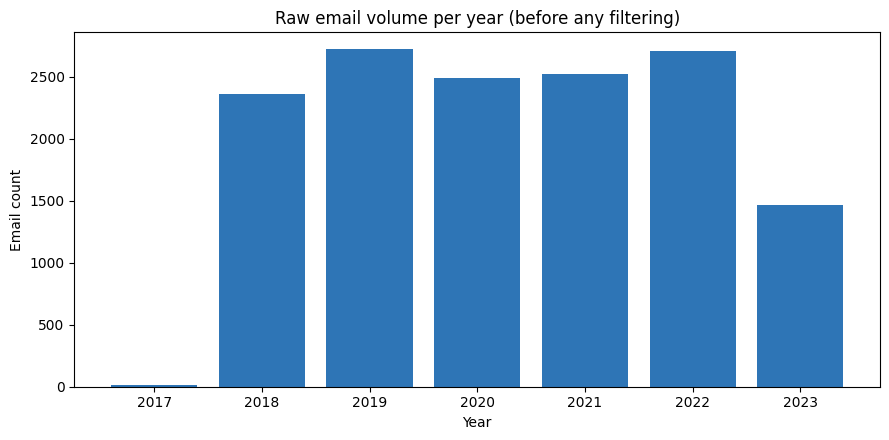

In [7]:
yearly_counts = dates.dt.year.value_counts().sort_index()
print(yearly_counts)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(yearly_counts.index.astype(int).astype(str), yearly_counts.values, color="#2E75B6")
ax.set_xlabel("Year")
ax.set_ylabel("Email count")
ax.set_title("Raw email volume per year (before any filtering)")
plt.tight_layout()
plt.savefig("/home/claude/eda_nb/fig_yearly_volume.png", dpi=150)
plt.show()

In [8]:
print("=== 2017 monthly breakdown ===")
print(dates[dates.dt.year == 2017].dt.month.value_counts().sort_index())
print()
print("=== 2023 monthly breakdown ===")
print(dates[dates.dt.year == 2023].dt.month.value_counts().sort_index())

=== 2017 monthly breakdown ===
Date
12    10
Name: count, dtype: int64

=== 2023 monthly breakdown ===
Date
1    186
2    219
3    281
4    149
5    225
6    252
7    157
Name: count, dtype: int64


2017: 10 emails (Dec only) -> drop. 2023: through July -> keep, annotate in yearly charts.

## 3. Content profiling

### 3.1 Message length distribution

count    14277.000000
mean      2109.997338
std       2510.381836
min          0.000000
25%        663.000000
50%       1173.000000
75%       2615.000000
max      35628.000000
Name: Message, dtype: float64


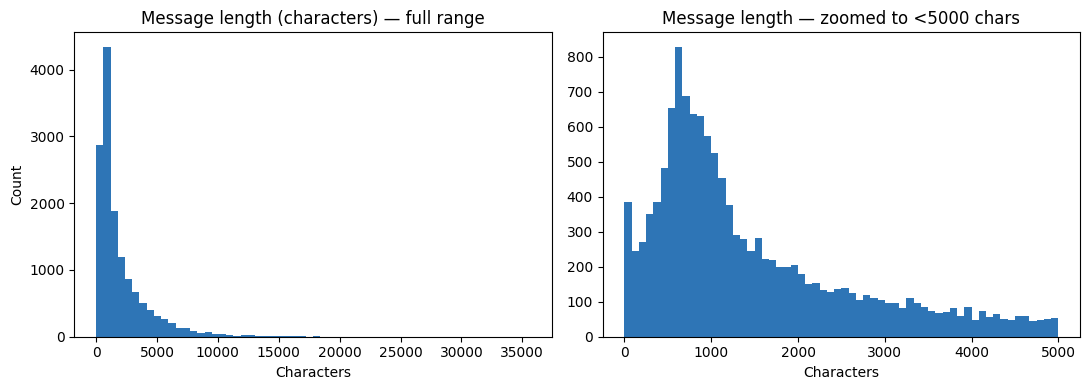

In [9]:
msg_len = df_clean["Message"].fillna("").str.len()
print(msg_len.describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(msg_len, bins=60, color="#2E75B6")
axes[0].set_title("Message length (characters) — full range")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(msg_len[msg_len < 5000], bins=60, color="#2E75B6")
axes[1].set_title("Message length — zoomed to <5000 chars")
axes[1].set_xlabel("Characters")
plt.tight_layout()
plt.savefig("/home/claude/eda_nb/fig_message_length.png", dpi=150)
plt.show()

In [10]:
n_very_short = (msg_len < 20).sum()
print(f"Messages under 20 characters: {n_very_short} ({n_very_short/len(df_clean)*100:.1f}%)")
df_clean.loc[msg_len < 20, ["Subject", "Message"]].head(10)

Messages under 20 characters: 285 (2.0%)


,Subject,Message
1,[ANNOUNCEMENTS] ΕΥΧΕΣ ΑΠΟ ΤΗ ΔΙΕΥΘΥΝΣΗ ΔΙΟΙΚΗΤΙΚΩΝ ΥΠΗΡΕΣΙΩΝ,
61,[ANNOUNCEMENTS] ΣΥΝΑΥΛΙΑ ΤΗΣ ΚΡΑΤΙΚΗΣ ΟΡΧΗΣΤΡΑΣ ΑΘΗΝΩΝ ΜΕ ΣΟΛΙΣΤ ΤΟΝ ΛΕΩΝΙΔΑ...,
80,[TOVIMA] Θεία Λειτουργία γιά τήν Ἑορτή τοῦ Μεγάλου Ἀθανασίου,
127,[TOVIMA] Θεία Λειτουργία γιά τήν Ἑορτή τοῦ Ἁγίου Γρηγορίου τοῦ Θε...,
187,[TOVIMA] Ἁγιασμόςγιά τόν μήναΦεβρουάριο,
326,[TOVIMA] Προηγιασμένη Θεία Λειτουργία,
331,[TOVIMA] Προηγιασμένη Θεία Λειτουργία,
355,[TOVIMA] Ἀκολουθία Α ́ Χαιρετισμῶν,
380,[TOVIMA] Προηγιασμένη Θεία Λειτουργία,
386,[TOVIMA] Ἁγιασμόςγιά τόν μήναΜάρτιο,


276 messages under 20 chars -> drop at the cleaning step.

### 3.2 Message length by year

In [11]:
yearly_median_len = msg_len.groupby(dates.dt.year).median()
print(yearly_median_len)

Date
2017.0     252.0
2018.0    1066.5
2019.0    1205.0
2020.0    1150.5
2021.0    1290.0
2022.0    1186.0
2023.0    1124.0
Name: Message, dtype: float64


2017 median length anomalous vs every other year.

### 3.3 HTML/CSS leakage

In [12]:
HTML_REGEX = re.compile(r"<[^>]+>")
STYLE_REGEX = re.compile(r"(style=|width:|padding:|border:)", re.IGNORECASE)

has_html = df_clean["Message"].str.contains(HTML_REGEX, regex=True)
has_style = df_clean["Message"].str.contains(STYLE_REGEX, regex=True)

print(f"Messages with HTML tags:        {has_html.sum()} ({has_html.mean()*100:.1f}%)")
print(f"Messages with inline CSS markers: {has_style.sum()} ({has_style.mean()*100:.1f}%)")
print(f"Either:                          {(has_html | has_style).sum()} ({(has_html | has_style).mean()*100:.1f}%)")

/tmp/ipykernel_678/1830587311.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_style = df_clean["Message"].str.contains(STYLE_REGEX, regex=True)


Messages with HTML tags:        2843 (19.9%)
Messages with inline CSS markers: 73 (0.5%)
Either:                          2916 (20.4%)


~20% of raw messages contain HTML/CSS remnants -> strip early.

### 3.4 Reply/forward chains in subject lines

In [13]:
reply_pattern = re.compile(r"\bRE:|\bΑΠ:|\bFW:|\bΠΡΘ:", re.IGNORECASE)
n_reply_chains = df_clean["Subject"].str.contains(reply_pattern, regex=True).sum()
print(f"Subjects indicating a reply/forward chain: {n_reply_chains} ({n_reply_chains/len(df_clean)*100:.1f}%)")

df_clean.loc[df_clean["Subject"].str.contains(reply_pattern, regex=True), "Subject"].head(8)

Subjects indicating a reply/forward chain: 899 (6.3%)


120    [TOVIMA] Re: [TOVIMA] Eνδόραμα '17, 26-27 Ιανουαρίου 2018, Πάτρα, Συνεδρι...
251    [TOVIMA] Re: Δημόσιαπαρουσίαση(14/2/18, 11πμ.) της Μεταπτυχιακής Διπλωματ...
260    [TOVIMA] Re: Δημόσιαπαρουσίασητης Μεταπτυχιακής Διπλωματικής Εργασίας τ...
261    [TOVIMA] Re: Δημόσιαπαρουσίασητης Μεταπτυχιακής Διπλωματικής Εργασίας τ...
263    [TOVIMA] Re: Δημόσιαπαρουσίασητης Μεταπτυχιακής Διπλωματικής Εργασίας τ...
284    [TOVIMA] Re: ΟΡΘΗ ΕΠΑΝΑΛΗΨΗ - Δημόσια παρουσίαση της Μεταπτυχιακής Διπλωμ...
290    [TOVIMA] Re: Δημόσιαπαρουσίασητης διδακτορικής διατριβής της Υ.Δ.Δέσποι...
333    [TOVIMA] RE: [TOVIMA] ΔΙΌΡΘΩΣΗ ΣΤΟ ΣΩΣΤΌ: Παρουσίαση Διπλωματικής Μεταπτ...
Name: Subject, dtype: str

~6% replies/forwards -> flag; quoted lines handled in NLP preprocessing.

### 3.5 Subject line list-tags — confirming the two source lists

In [14]:
tags = df_clean["Subject"].str.extract(r"^\[([A-Za-zΑ-Ωα-ω]+)\]")[0]
print(tags.value_counts(dropna=False))

0
TOVIMA           10087
ANNOUNCEMENTS     4137
NaN                 53
Name: count, dtype: int64


Two lists: [TOVIMA] ~71%, [ANNOUNCEMENTS] ~29%, 53 untagged.

## 4. Sender (`Author`) and recipient (`To`) field audit

### 4.1 Author cardinality and concentration

Unique authors: 1034 across 14277 emails

Author
Γραμματεία ΕΛΚΕ Πανεπιστημίου Πατρών            792
Πανεπιστημιακή Ενημέρωση                         488
Σύλλογος Διοικητικού Προσωπικού                 337
Οικονομική Υπηρεσία                              225
Dr. Dimitris Zois                                  214
Δ/ΝΣΗ ΔΙΟΙΚΗΤΙΚΩΝ ΥΠΗΡΕΣΙΩΝ-ΠΑΝΕΠΙΣΤΗΜΙΟ ΠΑΤΡΩΝ    213
Γραμματεία Συγκλήτου                             183
Γραφείο ΕπικοινωνίαςΤύπου                       180
Πρυτανικό Συμβούλιο                              177
Σωτηρόπουλος Αθανάσιος                           174
Vassilis Anastassopoulos                           161
John Matsoukas                                     160
Kostas Markou                                      155
Γραμματεία Πρυτανείας                            150
Σχολή Θετικών Επιστημών - Κοσμητεία            148
Name: count, dtype: int64


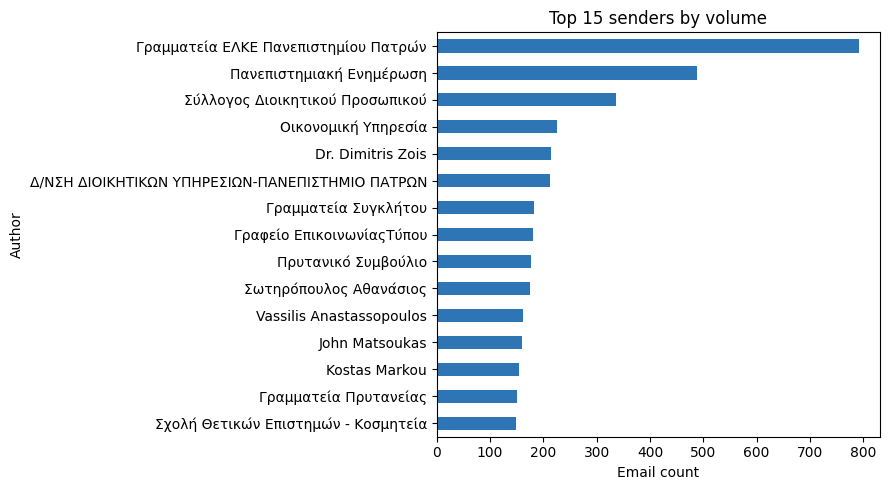

In [15]:
print(f"Unique authors: {df_clean['Author'].nunique()} across {len(df_clean)} emails")
print()
top_authors = df_clean["Author"].value_counts().head(15)
print(top_authors)

fig, ax = plt.subplots(figsize=(9, 5))
top_authors.sort_values().plot(kind="barh", ax=ax, color="#2E75B6")
ax.set_xlabel("Email count")
ax.set_title("Top 15 senders by volume")
plt.tight_layout()
plt.savefig("/home/claude/eda_nb/fig_top_authors.png", dpi=150)
plt.show()

Sender volume concentrated in a few institutional senders.

### 4.2 The `To` field

In [16]:
print(f"Unique raw 'To' values: {df_clean['To'].nunique()}")
print()
print(df_clean["To"].value_counts().head(20))

Unique raw 'To' values: 1981

To
tovima                                4958
announcements                         1892
Tovima                                1235
Announcements                         1108
announcements, tovima                  463
announcements, tovima, studentnews     268
ΑΝΑΚΟΙΝΩΣΕΙΣ, Info                     165
ΤΟ ΒΗΜΑ                                160
tovima UNIVERSITY                      143
ΑΝΑΚΟΙΝΩΣΕΙΣ                           133
toVima                                 113
tovima@upatras.gr                      103
announcements, studentnews              99
sdp, tovima                             98
tovima, announcements                   83
ANNOUNCEMENTS                           83
tovima, sdp                             80
Announcements, tovima                   73
ΤΜΗΜΑ ΓΕΩΛΟΓΙΑΣ                         68
tovima_upatras                          65
Name: count, dtype: int64


1,981 unique raw values for a handful of real lists -> needs normalization.

## 5. Embedded PII in message bodies

In [17]:
email_pattern = re.compile(r"[\w\.-]+@[\w\.-]+\.\w+")
phone_pattern = re.compile(r"\b(69\d{8}|2\d{9})\b")

n_with_email = df_clean["Message"].str.contains(email_pattern, regex=True).sum()
n_with_phone = df_clean["Message"].str.contains(phone_pattern, regex=True).sum()

print(f"Messages containing an embedded email address: {n_with_email} ({n_with_email/len(df_clean)*100:.1f}%)")
print(f"Messages containing a phone-like number:        {n_with_phone} ({n_with_phone/len(df_clean)*100:.1f}%)")

/tmp/ipykernel_678/2869282118.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_with_phone = df_clean["Message"].str.contains(phone_pattern, regex=True).sum()


Messages containing an embedded email address: 1196 (8.4%)
Messages containing a phone-like number:        1261 (8.8%)


~8-9% of bodies contain an email/phone -> flag; check before quoting any example.

## 6. Summary of findings

| # | Finding | Decision needed |
|---|---|---|
| 1 | 327 content-level duplicates vs. 115 full-row duplicates | Deduplicate on `(Subject, Message)`, not the full row |
| 2 | 3 unparseable dates | Safe to drop, negligible impact |
| 3 | 2017 (10 emails) and 2023 (7 months) are partial years | Exclude or explicitly annualize in any year-over-year analysis |
| 4 | 276 messages under 20 characters | Confirm `min_tokens` cutoff in preprocessing is an intentional response to this, not incidental |
| 5 | ~20% of messages contain HTML/CSS remnants | Move HTML/CSS stripping to an explicit, early, first-class cleaning step |
| 6 | ~6% of subjects are reply/forward chains | Decide whether to strip quoted-reply text from message bodies |
| 7 | `To` field has 1,981 raw unique values for a handful of real lists | Normalize if the field is to be used at all; otherwise explicitly document it as unused and why |
| 8 | ~8–9% of messages contain embedded personal contact info | Redact before quoting any example text in the thesis |
| 9 | Sender volume is highly concentrated among institutional/named senders | Acknowledge person-identifiability when reporting sender statistics; distinguish "institutional routine" clusters from genuine topic clusters in discussion |